# 07 — Ensemble Methods: Voting, Blending & Stacking

## Theory

### Why Ensembles Work
If base models have **diverse errors** (low pairwise correlation of residuals), combining them reduces variance:
$$\text{Var}(\bar{f}) = \frac{1}{n}\text{Var}(f_i) + \frac{n-1}{n}\text{Cov}(f_i, f_j)$$
Lower model correlation → lower ensemble variance → lower RMSE.

### Voting / Averaging
Simple weighted average of base model predictions:
$$\hat{y}_{\text{ensemble}} = \sum_i w_i \hat{y}_i$$

### Blending
1. Split train into **train/holdout** (e.g., 80/20)
2. Train base models on train portion
3. Generate predictions on holdout (these are the "blending" features)
4. Fit a **meta-learner** on the holdout predictions

### Stacking (Full Cross-Validation)
Same as blending but uses **K-fold OOF** predictions instead of a single holdout → uses all data, less variance in meta-learner training:
```
Fold 1: [===Train base===] → predict [OOF]
Fold 2: [====Train base====] → predict [OOF]
...
Stack OOF predictions → fit meta-learner
```

In [2]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor, VotingRegressor
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
#from sklearn.ensemble import GradientBoostingRegressor
#from sklearn.neighbors import KNeighborsRegressor

#from src.pipeline import build_pipeline, build_stacking_pipeline, build_preprocessor
from src.pipeline import build_pipeline, build_preprocessor
from src.evaluate import rmse, cv_score
from src.models import train_and_save, generate_oof_predictions
from src.features import FeatureEngineer

DATA_DIR = Path('../data')
PLOT_DIR = Path('../outputs/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'train.csv')
TARGET = 'resale_price'
X = train.drop(columns=[TARGET])
y = train[TARGET]

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=42)

# Log-transform target
y_log    = np.log(y)
y_tr_log = np.log(y_tr)
y_va_log = np.log(y_va)

kfcv = KFold(n_splits=5, shuffle=True, random_state=42)

print('Setup complete.')

Setup complete.


## 1. Base Model Residual Correlation

### LightGBM Hyperparameter History

| Hyperparameter | v1 Baseline (no log) | v2 Log-transform | v3 Regularisation | v4 XGB-tuned | v5 Optuna 100-trial (log) |
|---------------|---------------------|-----------------|------------------|-------------|-------------------------|
| `n_estimators` | 300 | 500 | 500 | 500 | 901 |
| `learning_rate` | 0.05 | 0.05 | 0.05 | 0.05 | 0.0666 |
| `num_leaves` | 127 | 127 | 63 | 63 | 176 |
| `max_depth` | — | — | — | — | 10 |
| `min_child_samples` | 20 | 20 | 50 | 50 | 13 |
| `colsample_bytree` | 1.0 | 1.0 | 0.8 | 0.8 | 0.7130 |
| `subsample` | 1.0 | 1.0 | 0.8 | 0.8 | 0.9541 |
| `subsample_freq` | 0 | 0 | 5 | 5 | 0 |
| `reg_alpha` | 0 | 0 | 0.1 | 0.1 | 0.0051 |
| `reg_lambda` | 0 | 0 | 0.1 | 0.1 | 0.0092 |
| **Optuna Best RMSE** | **—** | **—** | **—** | **—** | **S$22,030** |
| **LightGBM Val RMSE** | **S$25,156** | **S$23,689** | **S$23,218** | **S$23,227** | **S$21,874** |

---

### XGBoost Hyperparameter History

| Hyperparameter | v1 Baseline (no log) | v2 Log-transform | v3 Regularisation | v4 RandomizedSearchCV (no log) | v5 RandomizedSearchCV (log) |
|---------------|---------------------|-----------------|------------------|-------------------------------|----------------------------------|
| `n_estimators` | 300 | 500 | 500 | 627 | 517 |
| `learning_rate` | 0.3 (default) | 0.3 (default) | 0.3 (default) | 0.098 | 0.0429 |
| `max_depth` | 6 (default) | 6 (default) | 6 (default) | 9 | 11 |
| `subsample` | 1.0 (default) | 1.0 (default) | 1.0 (default) | 0.798 | 0.6888 |
| `colsample_bytree` | 1.0 (default) | 1.0 (default) | 1.0 (default) | 0.874 | 0.7219 |
| **XGBoost Val RMSE** | **S$23,868** | **S$23,284** | **S$23,230** | **S$22,069** | **S$21,876** |

In [3]:
base_pipelines = {
    'LightGBM': build_pipeline(LGBMRegressor(
        n_estimators=901, learning_rate=0.0666, num_leaves=176,
        max_depth=10, min_child_samples=13,
        colsample_bytree=0.7130, subsample=0.9541, subsample_freq=0,
        reg_alpha=0.0051, reg_lambda=0.0092,
        random_state=42, n_jobs=-1, verbose=-1), mode='tree'),
    'XGBoost':  build_pipeline(XGBRegressor(
        n_estimators=517, learning_rate=0.0429, max_depth=11,
        subsample=0.6888, colsample_bytree=0.7219,
        random_state=42, n_jobs=-1, verbosity=0), mode='tree'),
    #'Ridge':    build_pipeline(Ridge(alpha=10), mode='linear'),
    #'GBR':      build_pipeline(GradientBoostingRegressor(n_estimators=100, random_state=42), mode='tree'),
    #'KNN':      build_pipeline(KNeighborsRegressor(n_neighbors=15, n_jobs=-1), mode='linear'),
}

residuals = {}
val_preds = {}
for name, pipe in base_pipelines.items():
    pipe.fit(X_tr, y_tr_log)
    preds_log = pipe.predict(X_va)
    preds = np.exp(preds_log)
    val_preds[name] = preds
    residuals[name] = y_va.values - preds
    print(f'{name:<12} Val RMSE: S${rmse(y_va, preds):,.0f}')

resid_df = pd.DataFrame(residuals)
print('\nResidual Correlations:')
resid_df.corr()

LightGBM     Val RMSE: S$21,874
XGBoost      Val RMSE: S$21,876

Residual Correlations:


,LightGBM,XGBoost
LightGBM,1.000000,0.947541
XGBoost,0.947541,1.000000


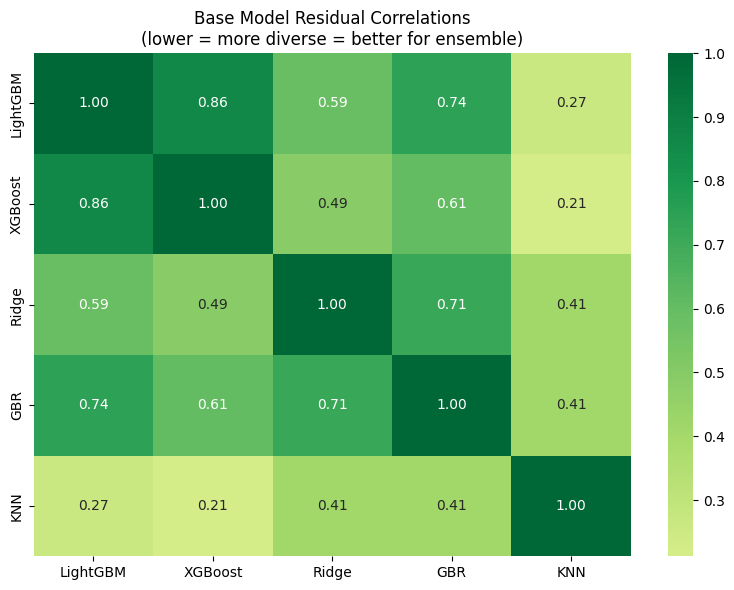

In [4]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(resid_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Base Model Residual Correlations\n(lower = more diverse = better for ensemble)')
fig.tight_layout()
fig.savefig(PLOT_DIR / 'residual_correlation.png', dpi=120)
plt.show()

## 2. Simple Voting Ensemble (Equal & Optimised Weights)

In [4]:
# Equal weights
val_pred_matrix = np.column_stack([val_preds[n] for n in base_pipelines])
equal_avg = val_pred_matrix.mean(axis=1)
equal_rmse = rmse(y_va, equal_avg)
print(f'Equal-weight average RMSE: S${equal_rmse:,.0f}')

# Optimised weights via scipy.optimize
def objective(weights):
    weights = np.abs(weights) / np.abs(weights).sum()  # normalise
    preds = val_pred_matrix @ weights
    return rmse(y_va, preds)

n_models = len(base_pipelines)
result = minimize(objective, x0=np.ones(n_models)/n_models,
                  method='SLSQP',
                  bounds=[(0, 1)] * n_models,
                  constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1})

opt_weights = result.x
opt_avg = val_pred_matrix @ opt_weights
opt_rmse = rmse(y_va, opt_avg)

print(f'Optimised-weight average RMSE: S${opt_rmse:,.0f}')
for name, w in zip(base_pipelines.keys(), opt_weights):
    print(f'  {name}: {w:.3f}')

Equal-weight average RMSE: S$21,586
Optimised-weight average RMSE: S$21,586
  LightGBM: 0.501
  XGBoost: 0.499


## 3. Stacking with sklearn StackingRegressor

In [7]:
#stacking_pipeline = build_stacking_pipeline()  # old: all 5 base models

from sklearn.pipeline import Pipeline
stacking_pipeline = Pipeline([
    ('fe', FeatureEngineer()),
    ('stack', StackingRegressor(
        estimators=[
            ('lgbm', Pipeline([('prep', build_preprocessor('tree')),
                               ('model', LGBMRegressor(
                                   n_estimators=997, learning_rate=0.0625, num_leaves=102,
                                   max_depth=12, min_child_samples=61,
                                   colsample_bytree=0.6208, subsample=0.8847, subsample_freq=0,
                                   reg_alpha=0.0738, reg_lambda=0.0091,
                                   random_state=42, n_jobs=-1, verbose=-1))])),
            ('xgb',  Pipeline([('prep', build_preprocessor('tree')),
                               ('model', XGBRegressor(
                                   n_estimators=627, learning_rate=0.098, max_depth=9,
                                   subsample=0.798, colsample_bytree=0.874,
                                   random_state=42, n_jobs=-1, verbosity=0))])),
        ],
        final_estimator=Ridge(alpha=1.0),
        passthrough=False,
        cv=5,
        n_jobs=-1,
    )),
])

print('Running stacking CV (LightGBM + XGBoost → Ridge meta-learner)...')
mean_r, std_r = cv_score(stacking_pipeline, X, y_log, cv=kfcv)
print(f'Stacking CV RMSE: S${np.exp(mean_r):,.0f}')


Running stacking CV (LightGBM + XGBoost → Ridge meta-learner)...
Stacking CV RMSE: S$23,506 ± S$347


## 4. Manual OOF Stacking

In [5]:
print('Generating OOF predictions for manual stacking...')
oof_df = generate_oof_predictions(base_pipelines, X, y_log, n_splits=5)

# Fit meta-learner on OOF predictions (log space)
meta = Ridge(alpha=1.0)
meta.fit(oof_df.values, y_log)
meta_preds_log = meta.predict(oof_df.values)
oof_rmse = rmse(y, np.exp(meta_preds_log))   # RMSE in SGD
print(f'OOF meta-learner RMSE (train): S${oof_rmse:,.0f}')


Generating OOF predictions for manual stacking...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
OOF predictions saved: /home/shl/m3-hdb-price-challenge/notebooks/../outputs/predictions/oof_predictions.csv
OOF meta-learner RMSE (train): S$21,900


In [6]:
# Evaluate meta-learner on held-out val set
oof_val_preds_log = np.column_stack([
    pipe.predict(X_va) for pipe in base_pipelines.values()
])
oof_val_rmse = rmse(y_va, np.exp(meta.predict(oof_val_preds_log)))
print(f'OOF meta-learner RMSE (val):   S${oof_val_rmse:,.0f}')


OOF meta-learner RMSE (val):   S$21,576


## 4b. OOF-Optimised Weight Blend
Optimise blend weights using OOF predictions (all training data) instead of a single holdout — produces more stable weights that generalise better to the test set.

In [15]:
# Reuse oof_df already computed above
oof_pred_matrix = oof_df.values

def oof_objective(weights):
    weights = np.abs(weights) / np.abs(weights).sum()
    return rmse(y, np.exp(oof_pred_matrix @ weights))

n_models = len(base_pipelines)
oof_result = minimize(oof_objective, x0=np.ones(n_models)/n_models,
                      method='SLSQP',
                      bounds=[(0, 1)] * n_models,
                      constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1})

oof_opt_weights = oof_result.x

# Evaluate on val set
val_pred_matrix = np.column_stack([val_preds[n] for n in base_pipelines])  # already exp'd
oof_blend_val_rmse = rmse(y_va, val_pred_matrix @ oof_opt_weights)

print(f'OOF-optimised blend Val RMSE: S${oof_blend_val_rmse:,.0f}')
for name, w in zip(base_pipelines.keys(), oof_opt_weights):
    print(f'  {name}: {w:.3f}')

OOF-optimised blend Val RMSE: S$21,586
  LightGBM: 0.517
  XGBoost: 0.483


## 5. Comparison Summary

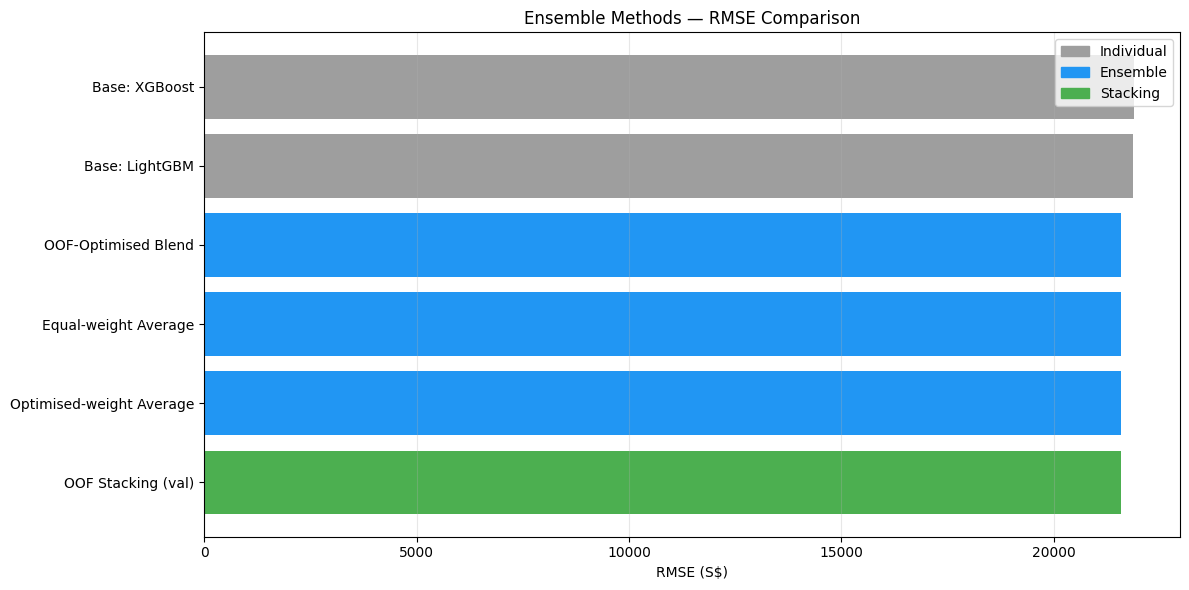

Best method: OOF Stacking (val) Val RMSE: S$21,576


,Method,Val RMSE,Type
5,OOF Stacking (val),21575.702747,Stacking
3,Optimised-weight Average,21586.073826,Ensemble
2,Equal-weight Average,21586.074371,Ensemble
4,OOF-Optimised Blend,21586.372549,Ensemble
0,Base: LightGBM,21874.092745,Individual
1,Base: XGBoost,21875.663874,Individual


In [16]:
individual_val_rmse = {name: rmse(y_va, val_preds[name]) for name in base_pipelines}

comparison = pd.DataFrame([
    *[{'Method': f'Base: {n}', 'Val RMSE': v, 'Type': 'Individual'}
      for n, v in individual_val_rmse.items()],
    {'Method': 'Equal-weight Average',      'Val RMSE': equal_rmse,         'Type': 'Ensemble'},
    {'Method': 'Optimised-weight Average',   'Val RMSE': opt_rmse,           'Type': 'Ensemble'},
    {'Method': 'OOF-Optimised Blend',        'Val RMSE': oof_blend_val_rmse, 'Type': 'Ensemble'},
    {'Method': 'OOF Stacking (val)',         'Val RMSE': oof_val_rmse,       'Type': 'Stacking'},
#    {'Method': 'Stacking (CV RMSE)',         'Val RMSE': mean_r,             'Type': 'Stacking'},
]).sort_values('Val RMSE')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#4CAF50' if t == 'Stacking' else '#2196F3' if t == 'Ensemble' else '#9E9E9E'
          for t in comparison.Type]
ax.barh(comparison.Method, comparison['Val RMSE'], color=colors)
ax.set_xlabel('RMSE (S$)')
ax.set_title('Ensemble Methods — RMSE Comparison')
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#9E9E9E', label='Individual'),
    Patch(color='#2196F3', label='Ensemble'),
    Patch(color='#4CAF50', label='Stacking'),
]
ax.legend(handles=legend_elements)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'ensemble_comparison.png', dpi=120)
plt.show()

print('Best method:', comparison.iloc[0]['Method'], f'Val RMSE: S${comparison.iloc[0]["Val RMSE"]:,.0f}')
comparison

### Ensemble Results History

| Metric | v1 Baseline (no log) | v2 Log-transform | v3 Regularisation | v4 XGB-tuned | v5 Optuna-tuned |
|--------|---------------------|-----------------|------------------|-------------|----------------|
| **Equal-weight Avg RMSE** | — | S$22,577 | S$22,344 | S$21,926 | S$21,586 |
| **Optimised-weight Avg RMSE** | S$22,751 | S$22,565 | S$22,344 | S$21,805 | S$21,586 |
| LightGBM weight (optimised) | 0.313 | — | 0.502 | 0.301 | 0.501 |
| XGBoost weight (optimised) | 0.687 | — | 0.498 | 0.699 | 0.499 |
| **OOF-Optimised Blend RMSE** | — | S$22,565 | S$22,345 | S$21,805 | S$21,586 |
| LightGBM weight (OOF blend) | — | — | 0.486 | 0.301 | 0.517 |
| XGBoost weight (OOF blend) | — | — | 0.514 | 0.699 | 0.483 |
| **OOF Stacking Val RMSE** | — | S$22,565 | S$22,350 | S$21,799 | S$21,576 |
| **Kaggle Test RMSE** | S$24,220 | S$23,044 | — | — | S$21,661 |

In [13]:
from pathlib import Path
from datetime import date

def log_model(model, notebook, key_params, train_rmse=None, val_rmse=None, test_rmse=None, notes=""):
    tracker_path = Path("../outputs/model_tracker.csv")
    row = {
        "date":       date.today().isoformat(),
        "model":      model,
        "notebook":   notebook,
        "key_params": key_params,
        "train_rmse": round(train_rmse) if train_rmse is not None else "",
        "val_rmse":   round(val_rmse)   if val_rmse   is not None else "",
        "test_rmse":  round(test_rmse)  if test_rmse  is not None else "",
        "notes":      notes,
    }
    tracker = pd.read_csv(tracker_path) if tracker_path.exists() else pd.DataFrame(columns=row.keys())
    tracker = pd.concat([tracker, pd.DataFrame([row])], ignore_index=True)
    tracker.to_csv(tracker_path, index=False)
    print(f'Logged: {model} | val={val_rmse:,.0f}' if val_rmse else f'Logged: {model}')


In [14]:
# Log all methods to tracker
def get_lgbm_params(pipe):
    p = pipe.named_steps["model"].get_params()
    return (f"n_estimators={p['n_estimators']} lr={p['learning_rate']} "
            f"num_leaves={p['num_leaves']} max_depth={p['max_depth']} "
            f"min_child_samples={p['min_child_samples']} log_target=True")

def get_xgb_params(pipe):
    p = pipe.named_steps["model"].get_params()
    return (f"n_estimators={p['n_estimators']} lr={p['learning_rate']} "
            f"max_depth={p['max_depth']} subsample={p['subsample']:.3f} "
            f"colsample_bytree={p['colsample_bytree']:.3f} log_target=True")

param_str = {
    "LightGBM": get_lgbm_params(base_pipelines["LightGBM"]),
    "XGBoost":  get_xgb_params(base_pipelines["XGBoost"]),
}

for name, vrmse in individual_val_rmse.items():
    log_model(name, "07_ensemble_stacking", param_str[name], val_rmse=vrmse)

log_model("Optimised-weight Blend (LGBM+XGB)", "07_ensemble_stacking",
          f"lgbm={oof_opt_weights[0]:.3f} xgb={oof_opt_weights[1]:.3f} log_target=True",
          val_rmse=oof_blend_val_rmse, notes="OOF-optimised weights")

log_model("OOF Stacking (LGBM+XGB->Ridge)", "07_ensemble_stacking",
          f"Ridge alpha=1.0 cv=5 | {param_str['LightGBM']} | {param_str['XGBoost']}",
          val_rmse=oof_val_rmse)


Logged: LightGBM | val=21,874
Logged: XGBoost | val=21,876
Logged: Optimised-weight Blend (LGBM+XGB) | val=21,586
Logged: OOF Stacking (LGBM+XGB->Ridge) | val=21,576
